In [4]:
import pandas as pd
import matplotlib.pyplot as plt
token3 = pd.read_csv(
    "../datasets/processed/erc_20/token3_apr1_to_may9.csv",
)



In [6]:
token3 = token3.copy()
token3["date"] = pd.to_datetime(token3["date"], utc=True, errors="coerce")

# (optional) drop bad rows if any
token3 = token3.dropna(subset=["date"])

# --- Time window ---
collapse_time = pd.Timestamp("2022-05-09 12:00:00", tz="UTC")
start_time = collapse_time - pd.Timedelta(days=30)

# --- Filter BEFORE groupby (major speedup) ---
token3_sub = token3[
    (token3["date"] >= start_time) &
    (token3["date"] <= collapse_time)
].copy()

# --- Transaction-level aggregation (minimal columns needed for your plots) ---
tx = (
    token3_sub
      .groupby(["block_number", "transaction_index"], sort=False)
      .agg(
          n_transfers=("value", "size"),
          first_time=("date", "min")
      )
      .reset_index()
)

# --- Hourly series ---
tx["hour"] = tx["first_time"].dt.floor("h")

hourly = (
    tx.groupby("hour")
      .agg(
          txn_count=("n_transfers", "size"),               # number of txns per hour
          avg_transfers_per_txn=("n_transfers", "mean")    # complexity proxy
      )
      .reset_index()
      .sort_values("hour")
)

# --- Fixed anomaly point you want to annotate ---
anomaly_time = pd.Timestamp("2022-05-05 21:00:00", tz="UTC")
anomaly_txn_count = 24384

# complexity value at that hour (for the red chart annotation)
anomaly_complex = hourly.loc[hourly["hour"] == anomaly_time, "avg_transfers_per_txn"].iloc[0]

hourly.head()
# --- Fixed anomaly point you want to annotate ---
anomaly_time = pd.Timestamp("2022-05-05 21:00:00", tz="UTC")
anomaly_txn_count = 24384

# (Optional sanity check: ensure the hour exists in your data)
# print(hourly[hourly["hour"] == anomaly_time])

# Helper: get the corresponding complexity value at that hour (for annotation)
anomaly_complex = hourly.loc[hourly["hour"] == anomaly_time, "avg_transfers_per_txn"].iloc[0]

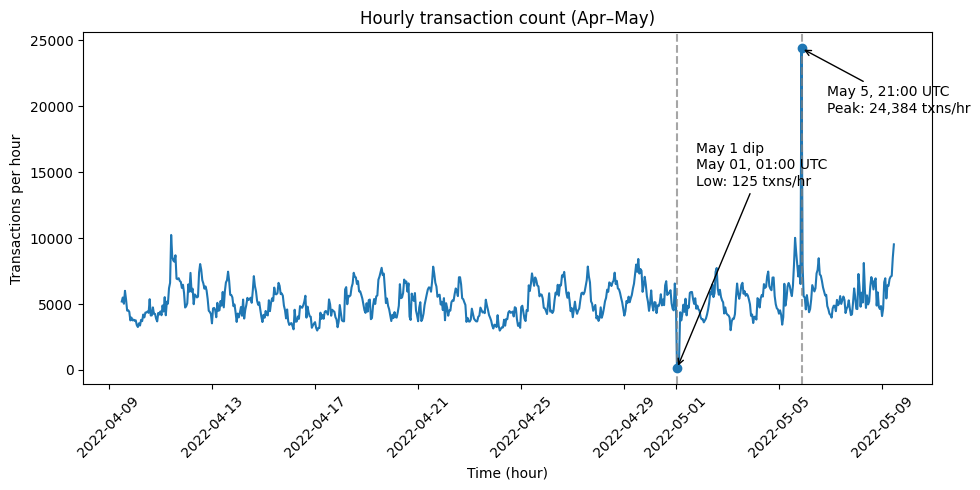

In [10]:
spike_time = pd.Timestamp("2022-05-05 21:00:00", tz="UTC")
spike_value = hourly.loc[hourly["hour"] == spike_time, "txn_count"].iloc[0]  # should be 24384

# Automatically find the lowest hour on May 1 (UTC)
may1 = hourly[(hourly["hour"] >= "2022-05-01") & (hourly["hour"] < "2022-05-02")]
dip_row = may1.loc[may1["txn_count"].idxmin()]
dip_time = dip_row["hour"]
dip_value = dip_row["txn_count"]

# --- Plot ---
plt.figure(figsize=(10, 5))
plt.plot(hourly["hour"], hourly["txn_count"], color="tab:blue")
plt.xlabel("Time (hour)")
plt.ylabel("Transactions per hour")
plt.title("Hourly transaction count (Apr–May)")
plt.xticks(rotation=45)

# vertical markers
plt.axvline(spike_time, linestyle="--", color="grey", alpha=0.7)
plt.axvline(dip_time, linestyle="--", color="grey", alpha=0.7)

# annotate spike
plt.scatter([spike_time], [spike_value], color="tab:blue", zorder=3)
plt.annotate(
    f"May 5, 21:00 UTC\nPeak: {int(spike_value):,} txns/hr",
    xy=(spike_time, spike_value),
    xytext=(spike_time + pd.Timedelta(hours=24), spike_value * 0.8),
    arrowprops=dict(arrowstyle="->"),
)

# annotate dip
plt.scatter([dip_time], [dip_value], color="tab:blue", zorder=3)
plt.annotate(
    f"May 1 dip\n{dip_time.strftime('%b %d, %H:%M UTC')}\nLow: {int(dip_value):,} txns/hr",
    xy=(dip_time, dip_value),
    xytext=(dip_time + pd.Timedelta(hours=18), 14000),  # <-- lifted into empty space
    arrowprops=dict(arrowstyle="->"),
)

plt.tight_layout()
plt.show()

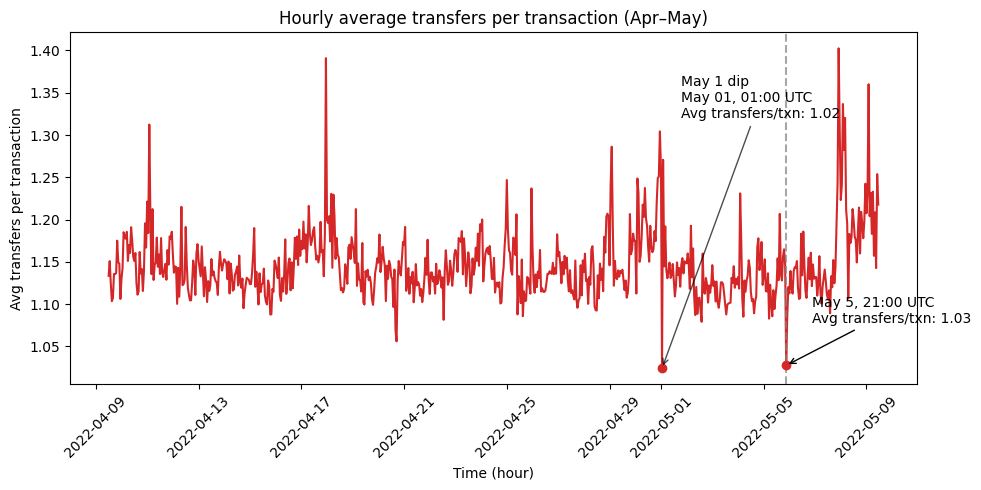

In [11]:
may1_complex = hourly[
    (hourly["hour"] >= "2022-05-01") &
    (hourly["hour"] <  "2022-05-02")
]

dip_complex_row = may1_complex.loc[may1_complex["avg_transfers_per_txn"].idxmin()]
dip_complex_time = dip_complex_row["hour"]
dip_complex_value = dip_complex_row["avg_transfers_per_txn"]

plt.figure(figsize=(10, 5))
plt.plot(hourly["hour"], hourly["avg_transfers_per_txn"], color="tab:red")
plt.axvline(anomaly_time, linestyle="--", color="grey", alpha=0.7)

plt.title("Hourly average transfers per transaction (Apr–May)")
plt.xlabel("Time (hour)")
plt.ylabel("Avg transfers per transaction")
plt.xticks(rotation=45)

# Annotate the May 5 anomaly (note: here it’s the corresponding low/level)
plt.scatter([anomaly_time], [anomaly_complex], color="tab:red", zorder=3)
plt.annotate(
    f"May 5, 21:00 UTC\nAvg transfers/txn: {anomaly_complex:.2f}",
    xy=(anomaly_time, anomaly_complex),
    xytext=(anomaly_time + pd.Timedelta(hours=24), anomaly_complex + 0.05),
    arrowprops=dict(arrowstyle="->"),
)


plt.scatter([dip_complex_time], [dip_complex_value], color="tab:red", zorder=3)

# Annotate (lifted into empty space)
plt.annotate(
    f"May 1 dip\n{dip_complex_time.strftime('%b %d, %H:%M UTC')}\nAvg transfers/txn: {dip_complex_value:.2f}",
    xy=(dip_complex_time, dip_complex_value),
    xytext=(dip_complex_time + pd.Timedelta(hours=18), 1.32),  # lifted upward
    arrowprops=dict(arrowstyle="->", alpha=0.7),
)
plt.tight_layout()
plt.show()